In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
import joblib

In [3]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)
        # add kelly USI feature data back
        # df_usi = pd.read_csv("../data/uci_phishing_url_dataset_new.csv")
        # col = df.pop("IsLegit")
        # df = pd.concat([df, df_usi[["Levenshtein", "JaroWinkler", "LCS"]]], axis=1)
        # # Add is Legit column back
        # df.insert(len(df.columns), "IsLegit", col)

        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [4]:
# Loads features and target variables
def load_data(filename, y_target_name, num_rows=-1, pos=0, isUCI_data: bool = True):
    df = pd.read_csv(filename)
    df = df.sample(frac=0.7).reset_index(drop=True)
    if not isUCI_data:
        df["Label"] = df["Label"].map({"Phishing": 0, "Legitimate": 1})
        df.rename(columns={"Label": "IsLegit"}, inplace=True)

    if num_rows > 0:
        df = df[pos : pos + num_rows]
    elif pos != 0:
        df = df[pos:]

    X = df.drop(columns=[y_target_name, "URL"])
    y = df[y_target_name]

    return X, y, df

In [5]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [
        df.columns[i]
        for i, item in enumerate(df.dtypes)
        if not pd.api.types.is_numeric_dtype(item)
    ]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32, 16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [6]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [7]:
def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    # Speed up cos -4,4 is too slow
    C_grid = np.logspace(-3, 3, 20)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print(f"working on {i} with C value: {C:.4f}")
        clf = LogisticRegression(C=C, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
            X_train, y_train
        )
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        # print(f"{y_train_pred=}")
        # print(f"{y_test_pred=}")
        print(f"{y_train_log_loss=:.4f}")
        print(f"{y_test_log_loss=:.4f}")
        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(
        C_grid,
        y_train_log_loss_data,
        "o-",
        color="blue",
        label="Training Data Log-Loss",
        markersize=3,
    )
    plt.plot(
        C_grid,
        y_test_log_loss_data,
        "o-",
        color="red",
        label="Test Data Log-Loss",
        markersize=3,
    )

    plt.xlabel("C")
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    # plt.ylim([0, 1])
    plt.xscale("log")
    plt.legend()
    plt.savefig("../outputs/logistic_regression_log_loss_c.png")

# Add kelly's calculated feature variables into the new data

In [8]:
# df_usi = pd.read_csv("../data/uci_phishing_url_dataset_new.csv")
# pd.concat([df, df_usi[["Levenshtein", "JaroWinkler", "LCS"]]], axis=1)

In [9]:
clean_csv(
    "../data/uci_phishing_url_dataset.csv",
    "../data/uci_phishing_url_dataset_clean.csv",
    [
        "Domain",
        "TLD",
        "Title",
        "DomainTitleMatchScore",
        "NoOfURLRedirect",
        "NoOfSelfRedirect",
        "HasDescription",
        "NoOfPopup",
        "HasExternalFormSubmit",
        "HasHiddenFields",
        "HasPasswordField",
        "Bank",
        "Pay",
        "Crypto",
        "NoOfCSS",
        "URLSimilarityIndex",
        "TLDLegitimateProb",
        "URLCharProb",
    ],
)

file: "../data/uci_phishing_url_dataset.csv" cleaned successfully


True

remove "FILENAME" column from data


# Why hardcode this data for ur USI columns?? @kellyyyc T_T not extensible is it?

In [10]:
# X, y, df = load_data("../data/uci_phishing_url_dataset_new.csv", "IsLegit", 100000)
# CSV_PATH = "../data/uci_phishing_url_dataset_clean.csv"
# CSV_PATH = "../data/uci_phishing_url_dataset_clean_stealth2025.csv"
CSV_PATH = "../data/uci_phishing_url_dataset_clean_stealth2025_noImage.csv"


# CSV_PATH = "../data/url_test_data_compatible-2.csv"
X, y, df = load_data(CSV_PATH, "IsLegit", False)

In [11]:
df

,URL,URLLength,DomainLength,IsDomainIP,CharContinuationRate,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,...,HasFavicon,Robots,HasSocialNet,HasSubmitButton,HasCopyrightInfo,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,IsLegit
0,http://bancaruralweb.0hi.me/?i=1,32,20,0,0.882353,2,1,0,0,0.0,...,1,1,1,1,0,0,0,0,0,0
1,http://www.saiconsard.co.jp.jtij.xyz/,37,29,0,0.523810,3,4,0,0,0.0,...,1,0,0,0,0,1,0,0,0,0
2,https://dappswalletnodes.firebaseapp.com/walle...,53,32,0,0.607143,3,1,0,0,0.0,...,1,1,1,1,0,0,0,0,0,0
3,https://www.web3helpers.xyz/,28,19,0,1.000000,3,1,0,0,0.0,...,1,1,1,1,0,1,1,0,1,0
4,https://servicepages-locked.start.page/,39,30,0,0.520000,4,1,0,0,0.0,...,1,1,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400776,https://www.eublockchainforum.eu,32,24,0,1.000000,2,1,0,0,0.0,...,1,1,1,1,0,3,44,0,24,1
400777,https://www.risenjesus.com,26,18,0,1.000000,3,1,0,0,0.0,...,0,0,1,0,0,28,89,3,84,1
400778,https://sites.google.com/view/pocswx/inicio,43,16,0,0.583333,3,1,0,0,0.0,...,1,1,1,1,0,0,0,0,0,0
400779,http://www.bafybeihknaezwv2ihboz4p6m55we4edira...,83,77,0,0.264706,4,3,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0


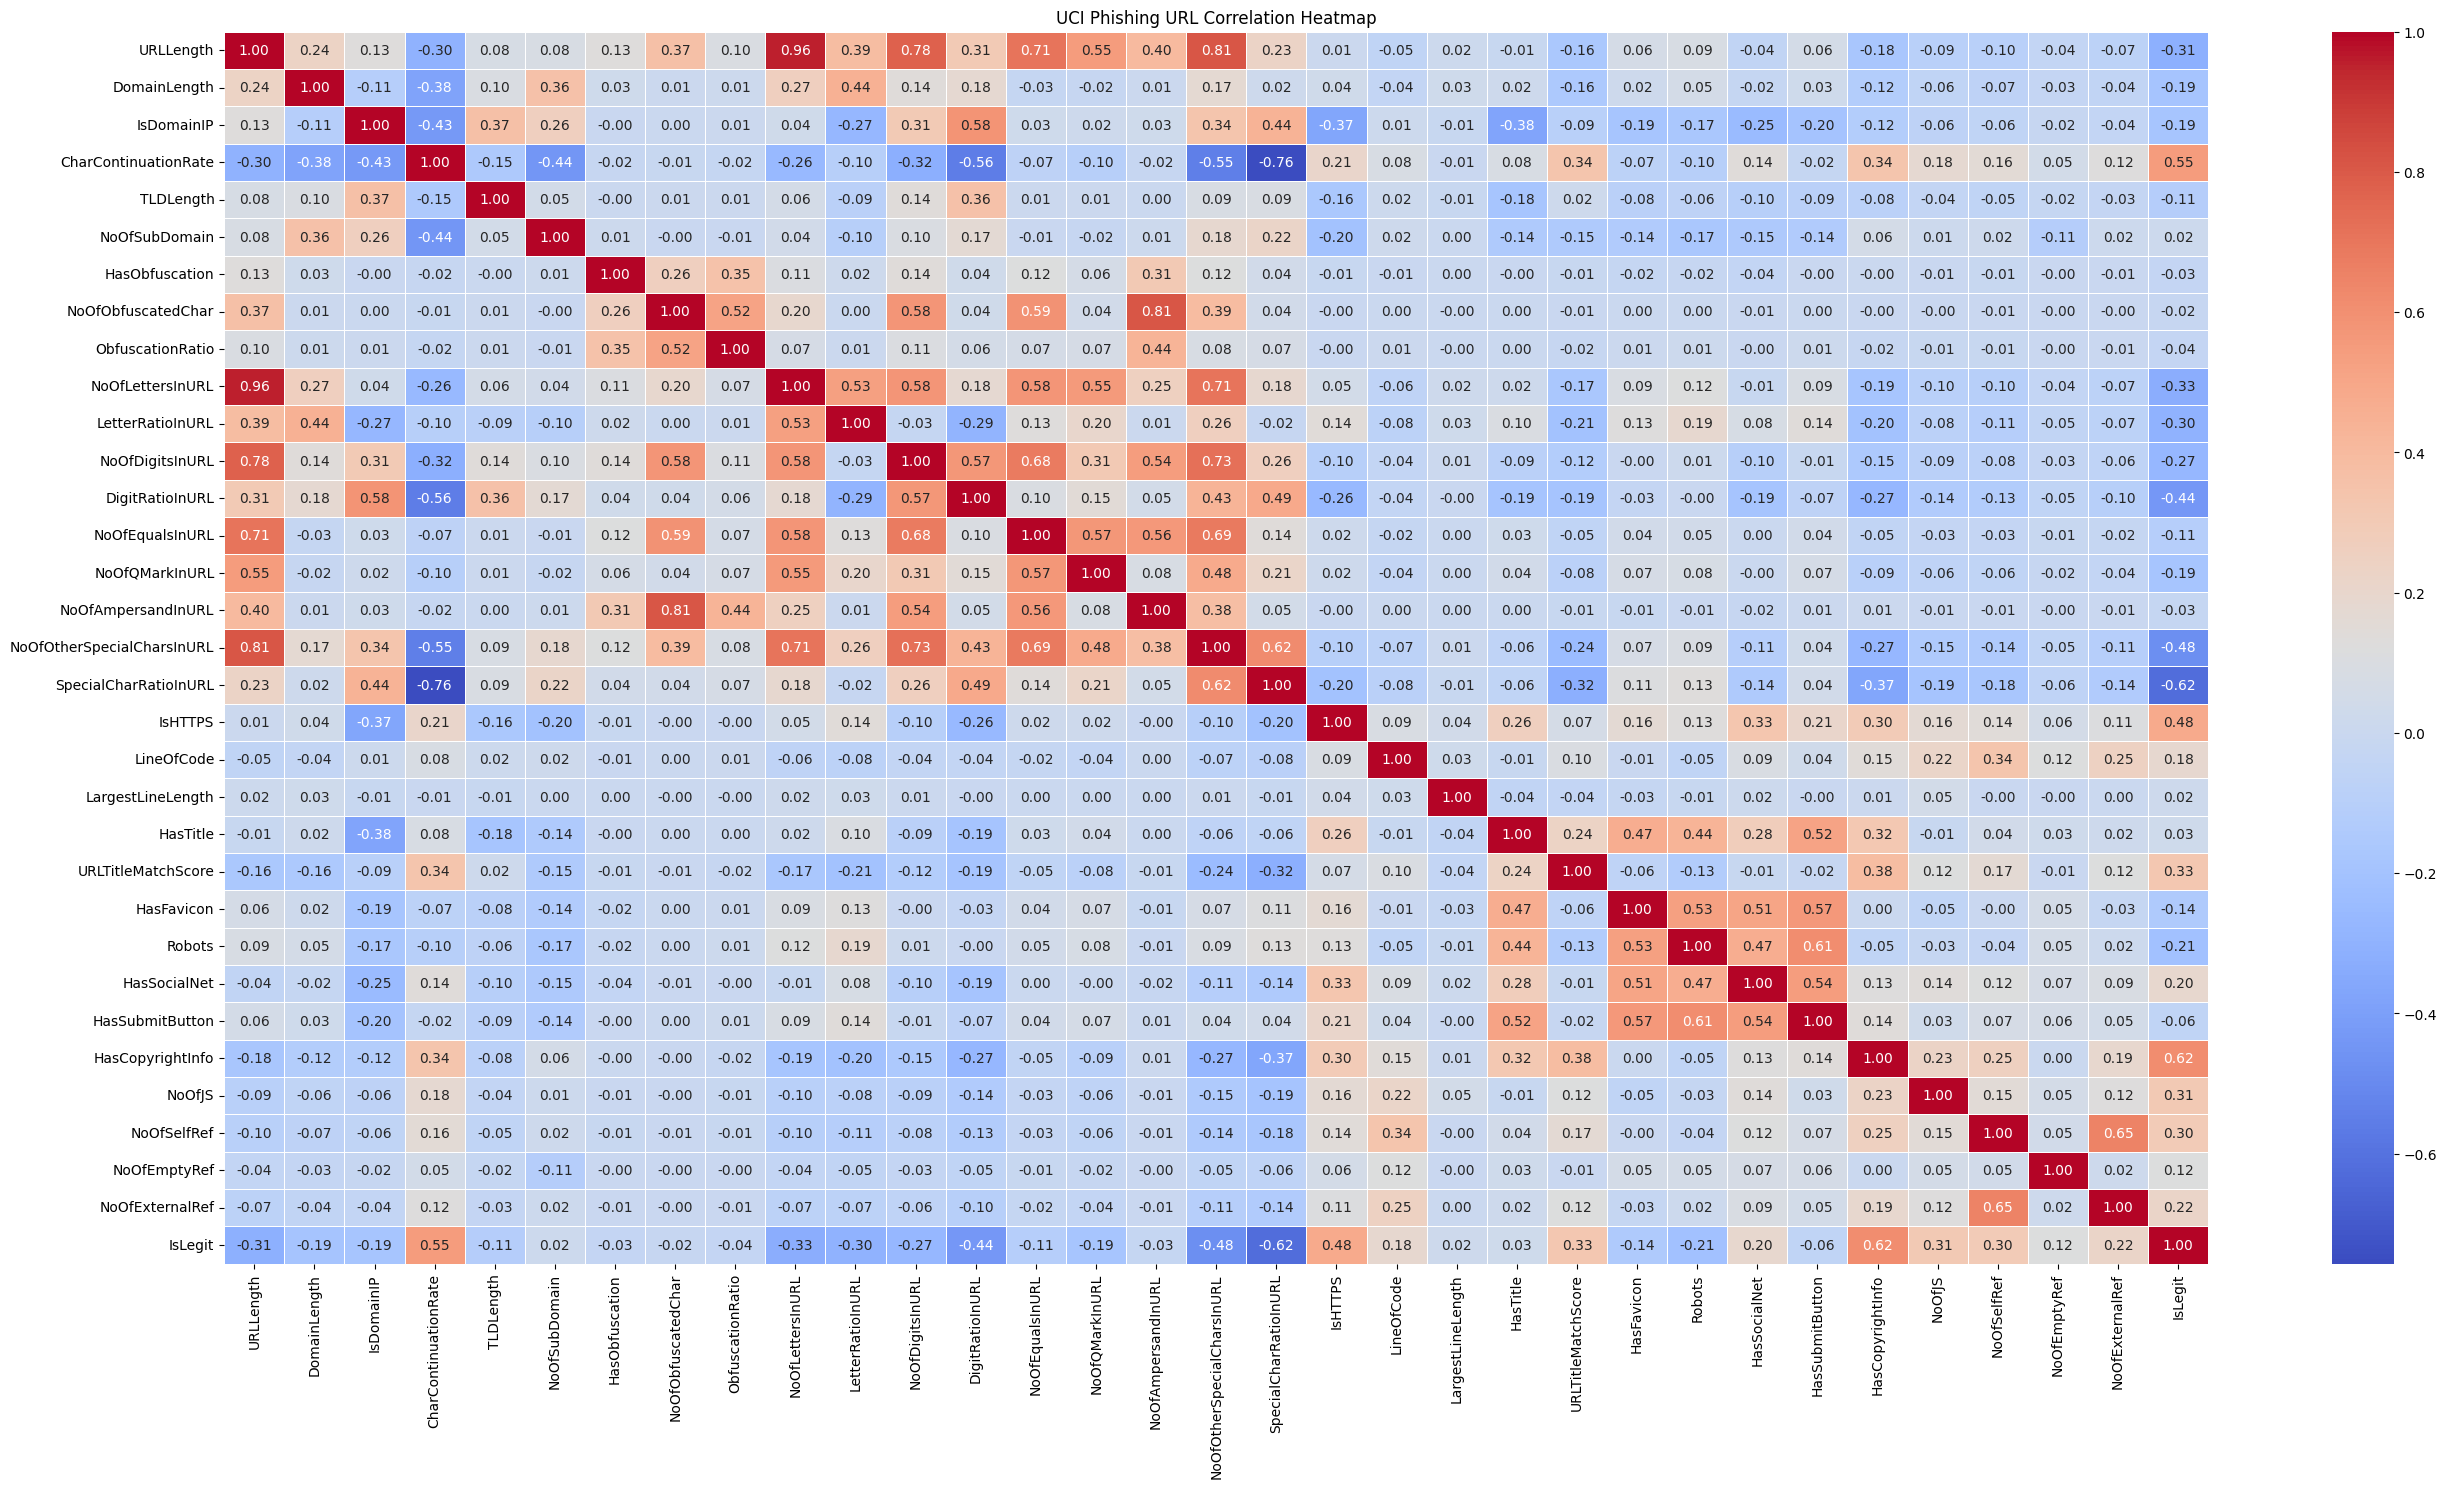

In [12]:
show_corr_matrix(df, "../outputs/corr_matrix_preprocessor.png")

In [13]:
X_train, X_test, y_train, y_test = get_training_test_data(X, y)
logistic_regression_model_training(X_train, X_test, y_train, y_test)

working on 0 with C value: 0.0010


/home/khalifa/pythonPackages/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.1104
y_test_log_loss=0.1119
working on 1 with C value: 0.0021


/home/khalifa/pythonPackages/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.1330
y_test_log_loss=0.1332
working on 2 with C value: 0.0043


...

/home/khalifa/pythonPackages/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.1062
y_test_log_loss=0.1076
working on 15 with C value: 54.5559


/home/khalifa/pythonPackages/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.1051
y_test_log_loss=0.1070
working on 16 with C value: 112.8838


KeyboardInterrupt: 

In [ ]:
clf = LogisticRegression(C=1, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
    X_train, y_train
)
# joblib.dump(
#     {"features": X_train.columns.tolist(), "model": clf}, "../models/logit_model.pkl"
# )

/home/khalifa/pythonPackages/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# joblib.dump(
#     {"features": X_train.columns.tolist(), "model": clf}, "../models/logit_model_2.pkl"
# )

['../models/logit_model_2.pkl']

## Move random forest model from model-diff into creation of model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report
import joblib

# Load data
X, y, df = load_data(CSV_PATH, "IsLegit", False)

# Train/test split
X_train, X_test, y_train, y_test = get_training_test_data(X, y)

# fit Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=0,
    n_jobs=-1,
    class_weight="balanced",
)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log loss:", log_loss(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(
    {"features": X_train.columns.tolist(), "model": rf},
    "../models/random_forest_model_2.pkl",
)

Accuracy: 0.9990847864967584
Log loss: 0.006863580880986932
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     69382
           1       1.00      1.00      1.00     73754

    accuracy                           1.00    143136
   macro avg       1.00      1.00      1.00    143136
weighted avg       1.00      1.00      1.00    143136



['../models/random_forest_model_2.pkl']

In [ ]:
model_dump = joblib.load("../models/logit_model_2.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_new, df_new = load_data(
    "../data/uci_phishing_url_dataset_clean.csv", "IsLegit", pos=100000
)
print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_new, y_new_pred)
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy}")

[[-3.34377769e-01  1.03759599e+00 -1.80406968e-02  1.65617317e-01
   5.34051484e-02  7.45473586e-02 -1.60198298e-04 -2.23440844e-03
  -3.38922651e-05 -7.74869012e-01  5.09482170e-03 -1.12103270e+00
  -3.19580688e-02 -5.93480347e-03 -5.93302264e-03 -9.14475134e-04
  -9.93640864e-01 -2.85080578e-02  5.42881664e-01  9.65456886e-05
   1.03408933e-06  4.68175888e-02 -1.65104845e-02 -1.56282662e-01
  -1.72426481e-01 -3.72898238e-02 -1.72641220e-01  3.01740927e-01
   6.00578559e-02  1.23632281e-01  1.23398762e-01  9.93208331e-02]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     69382
           1       1.00      1.00      1.00     73754

    accuracy                           1.00    143136
   macro avg       1.00      1.00      1.00    143136
weighted avg       1.00      1.00      1.00    143136

Accuracy: 0.9324427997653324


## Test against another external dataset, the stealth phishing dataset and kaggle dataset

### 50 url Samples of the StealthPhishing dataset

In [ ]:
model_dump = joblib.load("../models/logit_model_2.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_true, df_new = load_data(
    "../data/url_test_data_compatible-st-1.csv",
    "IsLegit",
)
# print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])
accuracy = accuracy_score(y_true, y_new_pred)
print(classification_report(y_true, y_new_pred))
print(f"Accuracy: {accuracy}")

              precision    recall  f1-score   support

           0       0.94      0.75      0.83        20
           1       0.79      0.95      0.86        20

    accuracy                           0.85        40
   macro avg       0.86      0.85      0.85        40
weighted avg       0.86      0.85      0.85        40

Accuracy: 0.85


### UCI original dataset

In [ ]:
model_dump = joblib.load("../models/logit_model_2.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_true, df_new = load_data(
    "../data/uci_phishing_url_dataset_clean_original_researchers.csv",
    "IsLegit",
)
# print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])
accuracy = accuracy_score(y_true, y_new_pred)
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     69382
           1       1.00      1.00      1.00     73754

    accuracy                           1.00    143136
   macro avg       1.00      1.00      1.00    143136
weighted avg       1.00      1.00      1.00    143136

Accuracy: 0.9336977035136453


### UCI dataset merged with Stealth phishing dataset 

In [ ]:
model_dump = joblib.load("../models/logit_model_2.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_true, df_new = load_data(
    "../data/uci_phishing_url_dataset_clean_stealth2025.csv",
    "IsLegit",
)
# print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_true, y_new_pred)
print(classification_report(y_true, y_new_pred))
print(f"Accuracy: {accuracy}")

              precision    recall  f1-score   support

           0       0.96      0.94      0.95    221417
           1       0.95      0.97      0.96    236618

    accuracy                           0.95    458035
   macro avg       0.95      0.95      0.95    458035
weighted avg       0.95      0.95      0.95    458035

Accuracy: 0.954182540635541


### Entire Stealth phishing dataset 

In [ ]:
model_dump = joblib.load("../models/logit_model_2.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_true, df_new = load_data(
    "../data/stealthphisher2025_uci_columns.csv",
    "IsLegit",
)
# print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_true, y_new_pred)
print(classification_report(y_true, y_new_pred))
print(f"Accuracy: {accuracy}")

              precision    recall  f1-score   support

           0       0.95      0.99      0.97    140732
           1       0.99      0.94      0.97    128667

    accuracy                           0.97    269399
   macro avg       0.97      0.97      0.97    269399
weighted avg       0.97      0.97      0.97    269399

Accuracy: 0.9679954268575607


## Kaggle dataset

In [1]:
model_dump = joblib.load("../models/logit_model_2.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_true, df_new = load_data(
    "../data/url_test_data_compatible-2.csv",
    "IsLegit",
)

# print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_true, y_new_pred)
print(classification_report(y_true, y_new_pred))
print(f"Accuracy: {accuracy}")

NameError: name 'joblib' is not defined

# compare between y_pred and y_expected:

In [6]:
y_new_pred

array([1, 1, 1, ..., 0, 0, 1], shape=(1141,))

In [7]:
y_true

0       1
1       1
2       1
3       1
4       1
       ..
1136    1
1137    1
1138    1
1139    1
1140    1
Name: IsLegit, Length: 1141, dtype: int64

## Run with Random forest model on stealth phishing dataset and kaggle dataset

In [83]:
model_dump = joblib.load("../models/random_forest_model_2.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_true, df_new = load_data(
    "../data/url_test_data_compatible-st-1.csv",
    "IsLegit",
)
# print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_true, y_new_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.86


## Kaggle dataset

In [84]:
model_dump = joblib.load("../models/random_forest_model_2.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_true, df_new = load_data(
    "../data/url_test_data_compatible-2.csv",
    "IsLegit",
)
# print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_true, y_new_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.33041191936897457
